In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib openpyxl

In [ ]:
import os
import glob
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)

RANDOM_STATE = 42

In [ ]:
uploaded = files.upload()

Saving Airline_Delay_Cause.csv to Airline_Delay_Cause.csv


In [ ]:
for file_name in uploaded.keys():
    if file_name.endswith(".csv"):
        os.rename(file_name, f"data/raw/{file_name}")

print("CSV files moved to data/raw/")
print(os.listdir("data/raw"))

CSV files moved to data/raw/
['Airline_Delay_Cause.csv']


In [ ]:
def load_and_merge_data(raw_folder="data/raw"):
    csv_files = glob.glob(os.path.join(raw_folder, "*.csv"))
    if not csv_files:
        raise FileNotFoundError("No CSV files found in data/raw")

    dfs = []
    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df["source_file"] = os.path.basename(file)
            dfs.append(df)
            print(f"Loaded: {file} | shape={df.shape}")
        except Exception as e:
            print(f"Skipped {file} due to error: {e}")

    if not dfs:
        raise ValueError("No valid CSV files loaded.")

    merged = pd.concat(dfs, ignore_index=True)
    print("Merged shape:", merged.shape)
    return merged

df_raw = load_and_merge_data()
df_raw.head()

Loaded: data/raw/Airline_Delay_Cause.csv | shape=(135557, 22)
Merged shape: (135557, 22)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,source_file
0,2025,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",90.0,29.0,15.33,0.09,...,7.93,3.0,0.0,2003.0,1024.0,12.0,192.0,0.0,775.0,Airline_Delay_Cause.csv
1,2025,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",44.0,14.0,5.89,1.80,...,6.12,0.0,0.0,1223.0,491.0,136.0,13.0,0.0,583.0,Airline_Delay_Cause.csv
2,2025,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",81.0,26.0,7.35,0.73,...,14.83,0.0,0.0,2162.0,588.0,33.0,205.0,0.0,1336.0,Airline_Delay_Cause.csv
3,2025,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",76.0,15.0,10.14,0.10,...,3.10,1.0,1.0,1695.0,975.0,20.0,272.0,0.0,428.0,Airline_Delay_Cause.csv
4,2025,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",56.0,24.0,5.17,1.00,...,13.44,4.0,0.0,2871.0,1397.0,21.0,212.0,0.0,1241.0,Airline_Delay_Cause.csv


In [ ]:
def preprocess_data(df):
    df = df.copy()

    # Rename columns (ONLY what you need)
    df = df.rename(columns={
        "carrier_name": "airline",
        "airport_name": "airport_name_full",
        "arr_flights": "total_flights",
        "arr_del15": "delayed_flights",
        "arr_cancelled": "cancelled_flights",
        "arr_diverted": "diverted_flights",
        "carrier_ct": "carrier_delay_count",
        "weather_ct": "weather_delay_count",
        "nas_ct": "nas_delay_count",
        "security_ct": "security_delay_count",
        "late_aircraft_ct": "late_aircraft_delay_count",
        "carrier_delay": "carrier_delay_minutes",
        "weather_delay": "weather_delay_minutes",
        "nas_delay": "nas_delay_minutes",
        "security_delay": "security_delay_minutes",
        "late_aircraft_delay": "late_aircraft_delay_minutes"
    })

    # Convert numeric
    numeric_cols = [
        "year","month","total_flights","delayed_flights","cancelled_flights","diverted_flights",
        "carrier_delay_count","weather_delay_count","nas_delay_count","security_delay_count","late_aircraft_delay_count",
        "carrier_delay_minutes","weather_delay_minutes","nas_delay_minutes","security_delay_minutes","late_aircraft_delay_minutes"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # Remove bad rows
    df = df[df["total_flights"] > 0]

    # Features
    df["total_delay_minutes"] = (
        df["carrier_delay_minutes"]
        + df["weather_delay_minutes"]
        + df["nas_delay_minutes"]
        + df["security_delay_minutes"]
        + df["late_aircraft_delay_minutes"]
    )

    df["delay_rate"] = df["delayed_flights"] / df["total_flights"]
    df["cancellation_rate"] = df["cancelled_flights"] / df["total_flights"]

    df["avg_delay_minutes_per_delayed_flight"] = (
        df["total_delay_minutes"] / df["delayed_flights"].replace(0,1)
    )

    df["season"] = df["month"].map({
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Fall",10:"Fall",11:"Fall"
    })

    return df

df = preprocess_data(df_raw)
df.head()

,year,month,carrier,airline,airport,airport_name_full,total_flights,delayed_flights,carrier_delay_count,weather_delay_count,...,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes,source_file,total_delay_minutes,delay_rate,cancellation_rate,avg_delay_minutes_per_delayed_flight,season
0,2025,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",90.0,29.0,15.33,0.09,...,12.0,192.0,0.0,775.0,Airline_Delay_Cause.csv,2003.0,0.322222,0.033333,69.068966,Winter
1,2025,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",44.0,14.0,5.89,1.80,...,136.0,13.0,0.0,583.0,Airline_Delay_Cause.csv,1223.0,0.318182,0.000000,87.357143,Winter
2,2025,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",81.0,26.0,7.35,0.73,...,33.0,205.0,0.0,1336.0,Airline_Delay_Cause.csv,2162.0,0.320988,0.000000,83.153846,Winter
3,2025,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",76.0,15.0,10.14,0.10,...,20.0,272.0,0.0,428.0,Airline_Delay_Cause.csv,1695.0,0.197368,0.013158,113.000000,Winter
4,2025,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",56.0,24.0,5.17,1.00,...,21.0,212.0,0.0,1241.0,Airline_Delay_Cause.csv,2871.0,0.428571,0.071429,119.625000,Winter


In [ ]:
df = preprocess_data(df_raw)
print(df.shape)
df.head()

(135293, 27)


,year,month,carrier,airline,airport,airport_name_full,total_flights,delayed_flights,carrier_delay_count,weather_delay_count,...,weather_delay_minutes,nas_delay_minutes,security_delay_minutes,late_aircraft_delay_minutes,source_file,total_delay_minutes,delay_rate,cancellation_rate,avg_delay_minutes_per_delayed_flight,season
0,2025,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",90.0,29.0,15.33,0.09,...,12.0,192.0,0.0,775.0,Airline_Delay_Cause.csv,2003.0,0.322222,0.033333,69.068966,Winter
1,2025,12,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",44.0,14.0,5.89,1.80,...,136.0,13.0,0.0,583.0,Airline_Delay_Cause.csv,1223.0,0.318182,0.000000,87.357143,Winter
2,2025,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",81.0,26.0,7.35,0.73,...,33.0,205.0,0.0,1336.0,Airline_Delay_Cause.csv,2162.0,0.320988,0.000000,83.153846,Winter
3,2025,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",76.0,15.0,10.14,0.10,...,20.0,272.0,0.0,428.0,Airline_Delay_Cause.csv,1695.0,0.197368,0.013158,113.000000,Winter
4,2025,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",56.0,24.0,5.17,1.00,...,21.0,212.0,0.0,1241.0,Airline_Delay_Cause.csv,2871.0,0.428571,0.071429,119.625000,Winter


In [ ]:
def aggregate_metrics(df):

    airport_metrics = df.groupby(["airport","airport_name_full"], as_index=False).agg({
        "total_flights":"sum",
        "delayed_flights":"sum",
        "cancelled_flights":"sum",
        "total_delay_minutes":"sum"
    })

    airport_metrics["delay_rate"] = airport_metrics["delayed_flights"] / airport_metrics["total_flights"]
    airport_metrics["cancellation_rate"] = airport_metrics["cancelled_flights"] / airport_metrics["total_flights"]
    airport_metrics["avg_delay_minutes"] = airport_metrics["total_delay_minutes"] / airport_metrics["delayed_flights"].replace(0,1)


    airline_metrics = df.groupby(["carrier","airline"], as_index=False).agg({
        "total_flights":"sum",
        "delayed_flights":"sum",
        "cancelled_flights":"sum",
        "total_delay_minutes":"sum"
    })

    airline_metrics["delay_rate"] = airline_metrics["delayed_flights"] / airline_metrics["total_flights"]
    airline_metrics["cancellation_rate"] = airline_metrics["cancelled_flights"] / airline_metrics["total_flights"]
    airline_metrics["avg_delay_minutes"] = airline_metrics["total_delay_minutes"] / airline_metrics["delayed_flights"].replace(0,1)

    return airport_metrics, airline_metrics


airport_metrics, airline_metrics = aggregate_metrics(df)

airport_metrics.head()

,airport,airport_name_full,total_flights,delayed_flights,cancelled_flights,total_delay_minutes,delay_rate,cancellation_rate,avg_delay_minutes
0,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",28774.0,5379.0,827.0,398985.0,0.186940,0.028741,74.174568
1,ABI,"Abilene, TX: Abilene Regional",10907.0,1767.0,244.0,106374.0,0.162006,0.022371,60.200340
2,ABQ,"Albuquerque, NM: Albuquerque International Sun...",130549.0,25479.0,2371.0,1445607.0,0.195168,0.018162,56.737195
3,ABR,"Aberdeen, SD: Aberdeen Regional",4377.0,498.0,68.0,47223.0,0.113777,0.015536,94.825301
4,ABY,"Albany, GA: Southwest Georgia Regional",5377.0,746.0,55.0,64200.0,0.138739,0.010229,86.058981


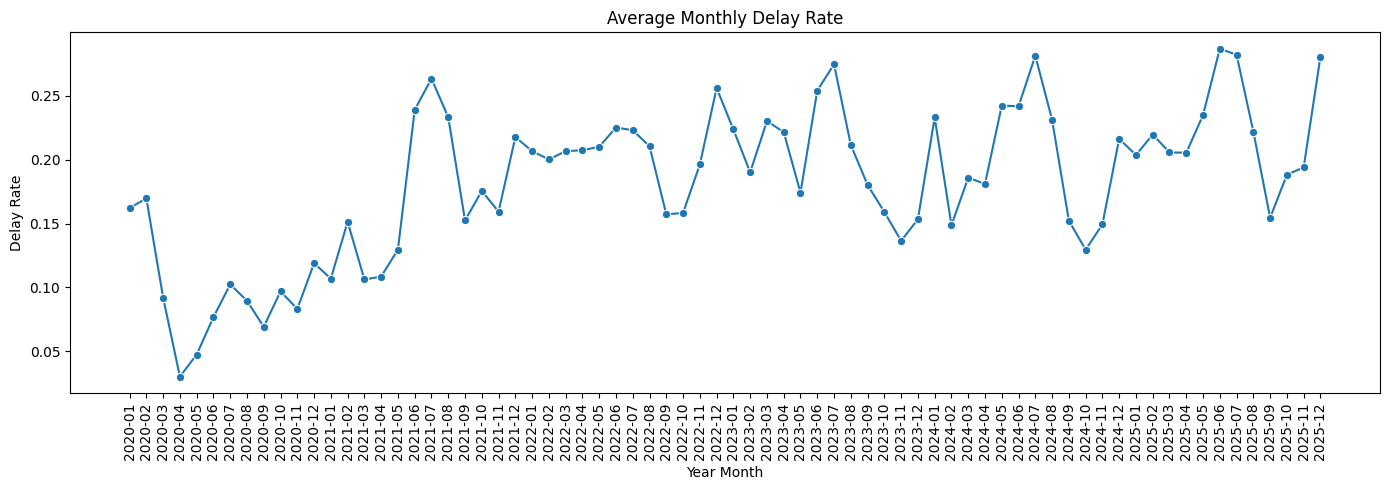

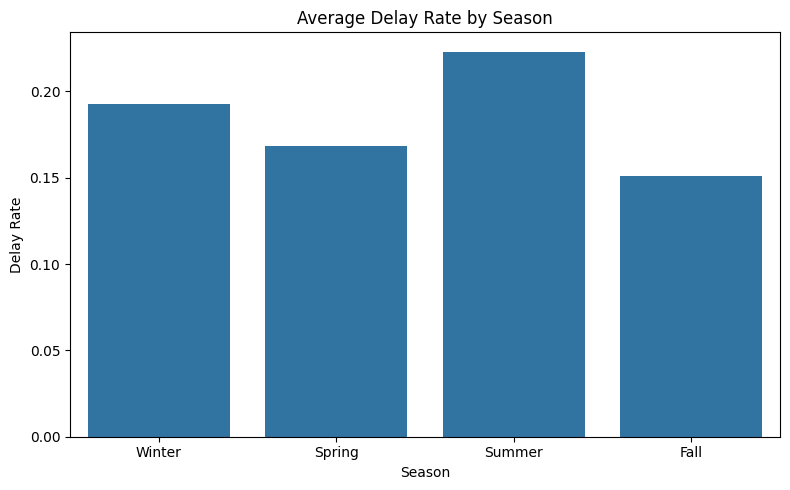

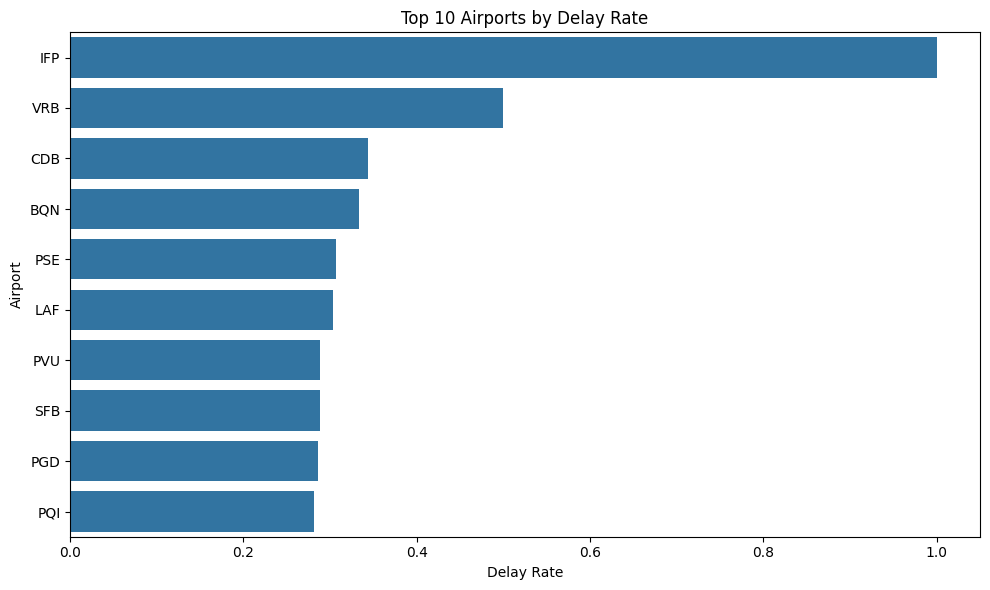

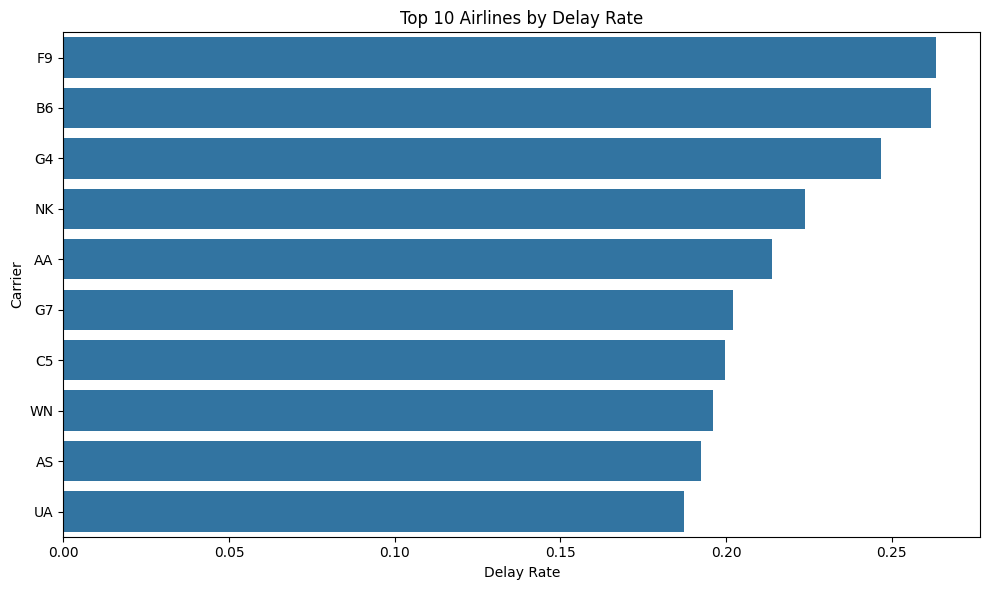

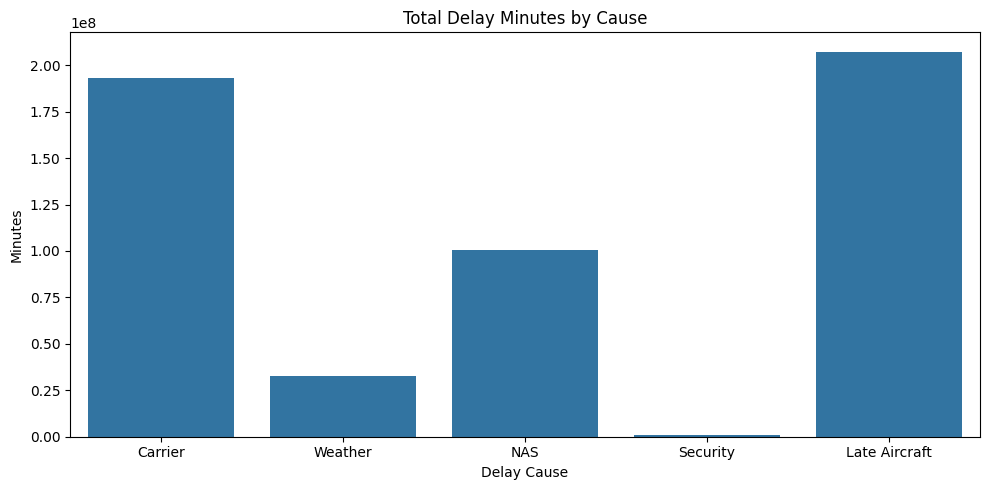

In [ ]:
def run_eda(df, airport_metrics, airline_metrics):
    monthly_delay = (
        df.groupby(["year", "month"], as_index=False)["delay_rate"]
        .mean()
        .sort_values(["year", "month"])
    )
    monthly_delay["year_month"] = (
        monthly_delay["year"].astype(str) + "-" + monthly_delay["month"].astype(str).str.zfill(2)
    )

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=monthly_delay, x="year_month", y="delay_rate", marker="o")
    plt.xticks(rotation=90)
    plt.title("Average Monthly Delay Rate")
    plt.xlabel("Year Month")
    plt.ylabel("Delay Rate")
    plt.tight_layout()
    plt.savefig("outputs/figures/monthly_delay_rate.png")
    plt.show()

    season_order = ["Winter", "Spring", "Summer", "Fall"]
    season_delay = df.groupby("season", as_index=False)["delay_rate"].mean()
    season_delay["season"] = pd.Categorical(season_delay["season"], categories=season_order, ordered=True)
    season_delay = season_delay.sort_values("season")

    plt.figure(figsize=(8, 5))
    sns.barplot(data=season_delay, x="season", y="delay_rate")
    plt.title("Average Delay Rate by Season")
    plt.xlabel("Season")
    plt.ylabel("Delay Rate")
    plt.tight_layout()
    plt.savefig("outputs/figures/seasonal_delay_rate.png")
    plt.show()

    top_airports = airport_metrics.sort_values("delay_rate", ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_airports, x="delay_rate", y="airport")
    plt.title("Top 10 Airports by Delay Rate")
    plt.xlabel("Delay Rate")
    plt.ylabel("Airport")
    plt.tight_layout()
    plt.savefig("outputs/figures/top_airports_delay_rate.png")
    plt.show()

    top_airlines = airline_metrics.sort_values("delay_rate", ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_airlines, x="delay_rate", y="carrier")
    plt.title("Top 10 Airlines by Delay Rate")
    plt.xlabel("Delay Rate")
    plt.ylabel("Carrier")
    plt.tight_layout()
    plt.savefig("outputs/figures/top_airlines_delay_rate.png")
    plt.show()

    cause_df = pd.DataFrame({
        "cause": ["Carrier", "Weather", "NAS", "Security", "Late Aircraft"],
        "minutes": [
            df["carrier_delay_minutes"].sum(),
            df["weather_delay_minutes"].sum(),
            df["nas_delay_minutes"].sum(),
            df["security_delay_minutes"].sum(),
            df["late_aircraft_delay_minutes"].sum()
        ]
    })

    plt.figure(figsize=(10, 5))
    sns.barplot(data=cause_df, x="cause", y="minutes")
    plt.title("Total Delay Minutes by Cause")
    plt.xlabel("Delay Cause")
    plt.ylabel("Minutes")
    plt.tight_layout()
    plt.savefig("outputs/figures/delay_minutes_by_cause.png")
    plt.show()

    monthly_delay.to_csv("outputs/tables/monthly_delay_rate.csv", index=False)
    season_delay.to_csv("outputs/tables/season_delay_rate.csv", index=False)
    top_airports.to_csv("outputs/tables/top_airports_delay_rate.csv", index=False)
    top_airlines.to_csv("outputs/tables/top_airlines_delay_rate.csv", index=False)
    cause_df.to_csv("outputs/tables/delay_minutes_by_cause.csv", index=False)

run_eda(df, airport_metrics, airline_metrics)

In [ ]:
def find_best_k(data, entity_name):
    features = ["delay_rate", "cancellation_rate", "avg_delay_minutes"]

    X = data[features].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    k_values = list(range(2, 6))
    silhouette_scores = []
    inertias = []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        inertias.append(kmeans.inertia_)

    best_k = k_values[int(np.argmax(silhouette_scores))]

    score_table = pd.DataFrame({
        "k": k_values,
        "silhouette_score": silhouette_scores,
        "inertia": inertias
    })

    plt.figure(figsize=(8, 5))
    plt.plot(k_values, silhouette_scores, marker="o")
    plt.title(f"Silhouette Scores for {entity_name}")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.tight_layout()
    plt.savefig(f"outputs/figures/{entity_name}_silhouette_scores.png")
    plt.show()

    score_table.to_csv(f"outputs/tables/{entity_name}_k_selection.csv", index=False)

    return best_k, scaler

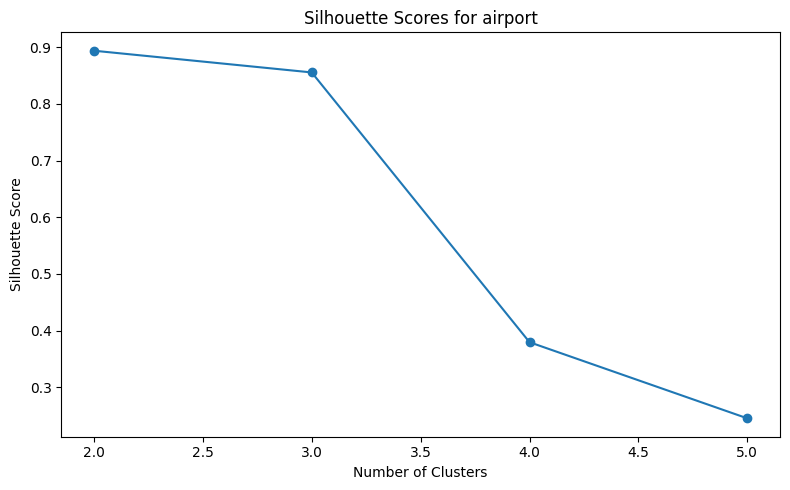

Best K for airport: 2


,cluster,delay_rate,cancellation_rate,avg_delay_minutes
0,0,0.176602,0.026625,72.669696
1,1,1.000000,0.000000,222.000000


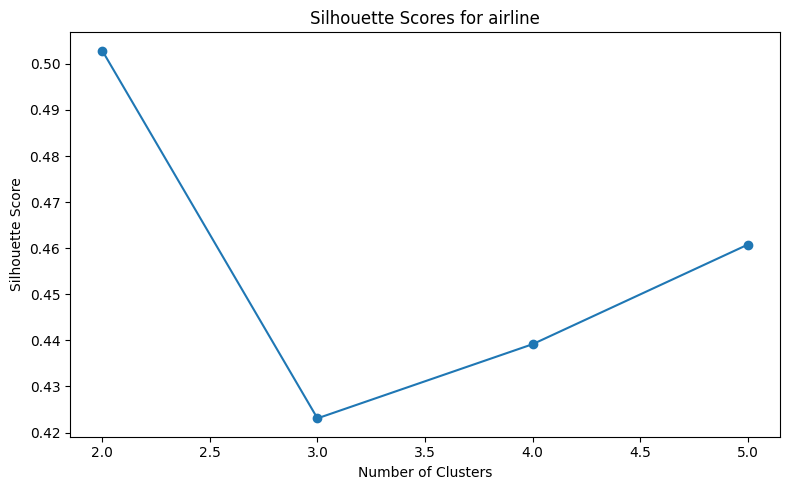

Best K for airline: 2


,cluster,delay_rate,cancellation_rate,avg_delay_minutes
0,0,0.118254,0.076151,66.234273
1,1,0.189006,0.024562,73.135703


In [ ]:
def cluster_entities(data, entity_name):
    features = ["delay_rate", "cancellation_rate", "avg_delay_minutes"]

    best_k, scaler = find_best_k(data, entity_name)
    X_scaled = scaler.fit_transform(data[features])

    kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    clustered = data.copy()
    clustered["cluster"] = kmeans.fit_predict(X_scaled)

    summary = (
        clustered.groupby("cluster", as_index=False)[features]
        .mean()
        .sort_values("delay_rate")
        .reset_index(drop=True)
    )

    clustered.to_csv(f"outputs/tables/{entity_name}_clustered.csv", index=False)
    summary.to_csv(f"outputs/tables/{entity_name}_cluster_summary.csv", index=False)

    joblib.dump(kmeans, f"outputs/models/{entity_name}_kmeans.pkl")
    joblib.dump(scaler, f"outputs/models/{entity_name}_scaler.pkl")

    print(f"Best K for {entity_name}: {best_k}")
    display(summary)

    return clustered, summary, best_k

airport_clustered, airport_summary, airport_k = cluster_entities(airport_metrics, "airport")
airline_clustered, airline_summary, airline_k = cluster_entities(airline_metrics, "airline")

In [ ]:
def run_baseline_models(df):
    model_df = df.copy()

    # SAMPLE DATA (VERY IMPORTANT)
    model_df = model_df.sample(n=50000, random_state=42)

    model_df["is_delayed"] = (model_df["delay_rate"] > 0.15).astype(int)

    feature_cols = [
        "year",
        "month",
        "total_flights",
        "cancelled_flights",
        "diverted_flights",
        "carrier_delay_count",
        "weather_delay_count",
        "nas_delay_count",
        "security_delay_count",
        "late_aircraft_delay_count"
    ]

    X = model_df[feature_cols]
    y_class = model_df["is_delayed"]
    y_reg = model_df["avg_delay_minutes_per_delayed_flight"]

    # Split
    X_train, X_test, y_train_c, y_test_c = train_test_split(
        X, y_class, test_size=0.2, random_state=42
    )

    # FAST MODEL
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    clf.fit(X_train, y_train_c)

    y_pred_c = clf.predict(X_test)

    classification_results = pd.DataFrame([{
        "accuracy": accuracy_score(y_test_c, y_pred_c),
        "f1_score": f1_score(y_test_c, y_pred_c)
    }])

    # Regression
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y_reg, test_size=0.2, random_state=42
    )

    reg = RandomForestRegressor(n_estimators=50, random_state=42)
    reg.fit(X_train_r, y_train_r)

    y_pred_r = reg.predict(X_test_r)

    regression_results = pd.DataFrame([{
        "mae": mean_absolute_error(y_test_r, y_pred_r),
        "rmse": mean_squared_error(y_test_r, y_pred_r) ** 0.5,
        "r2_score": r2_score(y_test_r, y_pred_r)
    }])

    print("Classification Results")
    display(classification_results)

    print("Regression Results")
    display(regression_results)

    return classification_results, regression_results


classification_results, regression_results = run_baseline_models(df)

Classification Results


,accuracy,f1_score
0,0.9518,0.958655


Regression Results


,mae,rmse,r2_score
0,21.397758,38.488692,0.166776


In [ ]:
print("===== REPORT READY SUMMARY =====")
print()

print(f"Airport clustering best K: {airport_k}")
print(f"Airline clustering best K: {airline_k}")
print()

print("Airport cluster summary:")
display(airport_summary)

print("Airline cluster summary:")
display(airline_summary)

print("Classification results:")
display(classification_results)

print("Regression results:")
display(regression_results)

print("Top 5 airports by delay rate:")
display(airport_metrics.sort_values("delay_rate", ascending=False).head(5))

print("Top 5 airlines by delay rate:")
display(airline_metrics.sort_values("delay_rate", ascending=False).head(5))

===== REPORT READY SUMMARY =====

Airport clustering best K: 2
Airline clustering best K: 2

Airport cluster summary:


,cluster,delay_rate,cancellation_rate,avg_delay_minutes
0,0,0.176602,0.026625,72.669696
1,1,1.000000,0.000000,222.000000


Airline cluster summary:


,cluster,delay_rate,cancellation_rate,avg_delay_minutes
0,0,0.118254,0.076151,66.234273
1,1,0.189006,0.024562,73.135703


Classification results:


...

,mae,rmse,r2_score
0,21.397758,38.488692,0.166776


Top 5 airports by delay rate:


,airport,airport_name_full,total_flights,delayed_flights,cancelled_flights,total_delay_minutes,delay_rate,cancellation_rate,avg_delay_minutes
188,IFP,"Bullhead City, AZ: Laughlin/Bullhead Internati...",1.0,1.0,0.0,222.0,1.000000,0.000000,222.000000
415,VRB,"Vero Beach, FL: Vero Beach Regional",42.0,21.0,1.0,1539.0,0.500000,0.023810,73.285714
69,CDB,"Cold Bay, AK: Cold Bay Airport",262.0,90.0,9.0,3212.0,0.343511,0.034351,35.688889
55,BQN,"Aguadilla, PR: Rafael Hernandez",12197.0,4070.0,286.0,277630.0,0.333689,0.023448,68.213759
318,PSE,"Ponce, PR: Mercedita",4043.0,1239.0,111.0,85238.0,0.306456,0.027455,68.795803


Top 5 airlines by delay rate:


,carrier,airline,total_flights,delayed_flights,cancelled_flights,total_delay_minutes,delay_rate,cancellation_rate,avg_delay_minutes
11,F9,Frontier Airlines,968030.0,255075.0,23192.0,19546403.0,0.263499,0.023958,76.630023
4,B6,JetBlue Airways,1366470.0,357799.0,34823.0,27724519.0,0.261842,0.025484,77.486295
12,G4,Allegiant Air,694895.0,171495.0,25650.0,13258817.0,0.246793,0.036912,77.313140
16,NK,Spirit Airlines,1278352.0,286328.0,28009.0,19869662.0,0.223982,0.021910,69.394757
1,AA,American Airlines Network,5078840.0,1086532.0,119543.0,87874824.0,0.213933,0.023537,80.876425
